# Cache-Augmented Generation (CAG)

**Cache-Augmented Generation (CAG)** combines fast caching layers with Retrieval-Augmented Generation (RAG) to eliminate redundant LLM inference, slash latency from seconds to milliseconds, and dramatically reduce operational API costs.

Standard RAG executes vector search and full LLM synthesis for **every incoming query**, even when identical or semantically similar questions have already been answered.

### CAG addresses this with a two-tier strategy:
1. **Exact-Match Caching**: Key-value lookup for verbatim queries (fastest, $O(1)$).
2. **Semantic Caching (FAISS-backed)**: Embeds incoming questions and checks vector distance against previously answered questions. Queries with semantic distance below a threshold are answered **instantly from cache** with **zero LLM tokens**.
3. **Dynamic RAG Fallback**: Only true cache misses trigger knowledge retrieval and LLM generation, automatically memoizing new answers into the cache for future queries.

## Workflow Architecture

<div align="center">
  <img src="workflow_architecture.png" alt="Cache-Augmented Generation (CAG) Architecture Diagram" width="500" />
</div>

<details>
<summary><b>Click to expand Colorful Mermaid Source Code</b></summary>

```mermaid
flowchart TD
    subgraph Client["Client Session"]
        User(["1. User Query"]):::startNode
    end

    subgraph Preprocessing["Query Normalization"]
        Norm["2. normalize_query<br/>(Lowercase and Strip Whitespace)"]:::normNode
    end

    subgraph SemanticCache["Semantic Cache Layer (FAISS)"]
        CacheLookup["3. semantic_cache_lookup<br/><b>FAISS FlatL2 Vector Search</b><br/>(HuggingFace MiniLM Embeddings)"]:::cacheNode
        Decision{"Cache Decision<br/>Distance <= Threshold?"}:::decideNode
        Hit["4. respond_from_cache<br/><b>Direct Cache Hit (0 Tokens)</b><br/>(Instant Return)"]:::hitNode
    end

    subgraph RAGPipeline["RAG Fallback on Cache Miss"]
        Retrieve["5. retrieve<br/><b>FAISS Knowledge Store</b><br/>(Fetch Context Docs)"]:::retrieveNode
        Generate["6. generate<br/><b>Groq LLM QA Synthesis</b><br/>(openai/gpt-oss-120b)"]:::genNode
        CacheWrite["7. cache_write<br/><b>Update Semantic Cache</b><br/>(Memoize Query + Answer + Timestamp)"]:::writeNode
    end

    Out(["8. Final Output Response"]):::endNode

    User --> Norm
    Norm --> CacheLookup
    CacheLookup --> Decision
    
    Decision -->|CACHE HIT: dist <= 0.35| Hit
    Decision -->|CACHE MISS: dist > 0.35| Retrieve
    
    Hit --> Out
    Retrieve --> Generate
    Generate --> CacheWrite
    CacheWrite --> Out

    classDef startNode fill:#E8F5E9,stroke:#2E7D32,stroke-width:2px,color:#1B5E20;
    classDef normNode fill:#E0F7FA,stroke:#00838F,stroke-width:2px,color:#004D40;
    classDef cacheNode fill:#FFF8E1,stroke:#FFA000,stroke-width:2px,color:#E65100;
    classDef decideNode fill:#FCE4EC,stroke:#C2185B,stroke-width:2px,color:#880E4F;
    classDef hitNode fill:#E8F8F5,stroke:#117A65,stroke-width:2px,color:#0E6251;
    classDef retrieveNode fill:#FFF3E0,stroke:#EF6C00,stroke-width:2px,color:#BF360C;
    classDef genNode fill:#F3E5F5,stroke:#7B1FA2,stroke-width:2px,color:#4A148C;
    classDef writeNode fill:#E3F2FD,stroke:#1565C0,stroke-width:2px,color:#0D47A1;
    classDef endNode fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#B71C1C;
```
</details>

### Key Architectural Highlights
- **Zero-Latency Semantic Hits**: Reuses high-quality generated answers for rephrased questions without calling the LLM.
- **Local Embedding Space**: Uses `sentence-transformers/all-MiniLM-L6-v2` locally for ultra-fast distance calculations.
- **Stateful Graph Orchestration**: LangGraph coordinates normalization, cache probing, fallback retrieval, and cache updating.


## Step 0: Environment Setup

Load environment variables from `.env` and initialize the **Groq LLM** (`openai/gpt-oss-120b`).

**Required Python packages:**
```bash
pip install langchain langchain-community langchain-groq langchain-huggingface \
            faiss-cpu langgraph python-dotenv sentence-transformers
```


In [1]:
import os
import time
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

# Load environment variables from .env
load_dotenv()
os.environ['USER_AGENT'] = os.getenv('USER_AGENT', 'CAG/1.0')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

# Initialize Groq Chat Model
llm = init_chat_model('groq:openai/gpt-oss-120b')
print('Environment loaded and Groq LLM initialized successfully.')
llm


Environment loaded and Groq LLM initialized successfully.


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001C7838B1D30>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001C7838B27B0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

## Part 1: Exact-Match Caching (Naive Baseline)

We first examine exact-match in-memory caching using a Python dictionary. While exact caching is lightning-fast for identical string queries, it fails when queries are even slightly rephrased.


In [2]:
# In-memory dictionary cache for exact match
Model_Cache = {}

def cache_model(query: str):
    """Exact-match caching function with latency timing."""
    if query in Model_Cache:
        print(f'*** CACHE HIT (EXACT MATCH) *** -> Query: "{query}"')
        print('EXECUTION TIME: 0.00 seconds (Instant Response)')
        return Model_Cache.get(query)
    else:
        print(f'*** CACHE MISS – EXECUTING MODEL *** -> Query: "{query}"')
        start_time = time.time()
        response = llm.invoke(query)
        end_time = time.time()
        elapsed = end_time - start_time
        print(f'EXECUTION TIME: {elapsed:.2f} seconds')
        Model_Cache[query] = response.content
        return response.content

# 1. First call: Cache Miss (invokes model)
res1 = cache_model('hi')
print('Response:', res1[:80], '...\n')

# 2. Second call with identical string: Cache Hit (instant)
res2 = cache_model('hi')
print('Response:', res2[:80], '...\n')


*** CACHE MISS – EXECUTING MODEL *** -> Query: "hi"
EXECUTION TIME: 0.73 seconds
Response: Hello! How can I help you today? ...

*** CACHE HIT (EXACT MATCH) *** -> Query: "hi"
EXECUTION TIME: 0.00 seconds (Instant Response)
Response: Hello! How can I help you today? ...



### Demonstrating the Limitation of Exact-Match Caching

Notice what happens below: Query 1 and Query 2 are identical, triggering a cache hit. But Query 3 is slightly rephrased (*"give me 500 words..."* vs *"can you give me 500 words..."*), resulting in a **Cache Miss** and re-executing full LLM inference!


In [3]:
# Query A: First execution -> Cache Miss
q_a = 'can you give me 500 words on langgraph?'
res_a = cache_model(q_a)
print(f'Length: {len(res_a)} characters\n')

# Query A (Repeated): Cache Hit
res_a_repeat = cache_model(q_a)
print(f'Length: {len(res_a_repeat)} characters\n')

# Query B (Slight variation: omitted 'can you'): CACHE MISS!
q_b = 'give me 500 words on langgraph?'
res_b = cache_model(q_b)
print(f'Length: {len(res_b)} characters\n')


*** CACHE MISS – EXECUTING MODEL *** -> Query: "can you give me 500 words on langgraph?"
EXECUTION TIME: 4.03 seconds
Length: 7888 characters

*** CACHE HIT (EXACT MATCH) *** -> Query: "can you give me 500 words on langgraph?"
EXECUTION TIME: 0.00 seconds (Instant Response)
Length: 7888 characters

*** CACHE MISS – EXECUTING MODEL *** -> Query: "give me 500 words on langgraph?"
EXECUTION TIME: 3.41 seconds
Length: 6479 characters



## Part 2: Advanced Semantic Caching with LangGraph (Semantic CAG)

To overcome exact-match limitations, **Semantic CAG** represents queries in a dense embedding space using `sentence-transformers/all-MiniLM-L6-v2`. When a query arrives:
1. It is normalized (lowercased and stripped).
2. Its vector distance to existing cached questions in `QA_CACHE` is calculated.
3. If the nearest neighbor distance $\le \text{THRESHOLD}$ (e.g. `0.35`), it is classified as a **Semantic Cache Hit** and returns the pre-computed answer immediately.
4. Only when distance $> \text{THRESHOLD}$ does it proceed to vector retrieval, Groq generation, and dynamic cache insertion.


## Step 1: Configuration & HuggingFace Embeddings

We initialize **`sentence-transformers/all-MiniLM-L6-v2`** via `HuggingFaceEmbeddings` and configure distance gates.


In [4]:
from langchain_huggingface import HuggingFaceEmbeddings

# Configuration Parameters
EMBED_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
VECTOR_DIM = 384
CACHE_DISTANCE_THRESHOLD = 0.35  # L2 distance gate (lower = more similar)
RETRIEVE_TOP_K = 4
CACHE_TOP_K = 1 # top 1 result from cache

# Initialize HuggingFace Embeddings
EMBED = HuggingFaceEmbeddings(model_name=EMBED_MODEL)
print('HuggingFace embedding model initialized successfully.')


c:\RAG\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10309.84it/s]


HuggingFace embedding model initialized successfully.


## Step 2: Initialize Semantic QA Cache and RAG Knowledge Store

- **`QA_CACHE`**: An initially empty FAISS index storing previously asked questions along with their answers and timestamps in metadata.
- **`RAG_STORE`**: A FAISS vector store containing our authoritative knowledge corpus.


In [5]:
import faiss
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore

# 1. Initialize Semantic QA Cache (starts empty)
qa_index = faiss.IndexFlatL2(VECTOR_DIM)
QA_CACHE = FAISS(
    embedding_function=EMBED,
    index=qa_index,
    docstore=InMemoryDocstore({}),
    index_to_docstore_id={},
)

# 2. Initialize RAG Knowledge Store with domain knowledge
RAG_STORE = FAISS.from_texts(
    texts=[
        'LangGraph lets you compose stateful LLM workflows as cyclic computation graphs.',
        'In LangGraph, nodes can be cached; node caching memoizes outputs keyed by inputs.',
        'Retrieval-Augmented Generation (RAG) retrieves external context and injects it into prompts.',
        'Semantic caching reuses prior answers when new questions are semantically similar.',
        'LangGraph agents utilize conditional edges to make autonomous routing and tool-use decisions.',
        'Checkpointers in LangGraph store thread-scoped states across multi-turn user dialogues.',
    ],
    embedding=EMBED,
)

print(f'RAG Store initialized with {RAG_STORE.index.ntotal} vectors.')
print(f'QA Cache initialized with {QA_CACHE.index.ntotal} vectors (ready for dynamic caching).')


RAG Store initialized with 6 vectors.
QA Cache initialized with 0 vectors (ready for dynamic caching).


C:\Users\itsar\AppData\Local\Temp\ipykernel_6948\2523274207.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


## Step 3: Define Graph State

We define `RAGState` (`TypedDict`) to track the question, normalization, retrieved documents, cache hit status, distance score, and generated answer.


In [6]:
from typing import TypedDict, List, Optional
from langchain_core.documents import Document

class RAGState(TypedDict):
    """
    Shared state of the Cache-Augmented Generation (CAG) workflow.
    """
    question: str
    normalized_question: str
    context_docs: List[Document]
    answer: Optional[str]
    citations: List[str]
    cache_hit: bool
    distance: Optional[float]

print('RAGState schema defined successfully.')


RAGState schema defined successfully.


## Step 4: Define LangGraph Workflow Nodes

1. **`normalize_query`**: Strips and lowercases the input query for consistent representations.
2. **`semantic_cache_lookup`**: Checks `QA_CACHE` for nearest question. If $L_2 \le 0.35$, flags `cache_hit = True` and loads cached answer.
3. **`respond_from_cache`**: Passes cached answer directly to output.
4. **`retrieve`**: On cache miss, queries `RAG_STORE` for top candidate chunks.
5. **`generate`**: Synthesizes a grounded answer using Groq LLM and retrieved context.
6. **`cache_write`**: Writes the new question-answer pair into `QA_CACHE` for subsequent queries.


In [7]:
def normalize_query(state: RAGState) -> RAGState:
    """Normalize query string by lowercasing and stripping whitespace."""
    q = (state['question'] or '').strip()
    state['normalized_question'] = q.lower()
    return state

def semantic_cache_lookup(state: RAGState) -> RAGState:
    """Query FAISS semantic QA cache for similar prior questions."""
    q = state['normalized_question']
    state['cache_hit'] = False
    state['distance'] = None

    if not q or getattr(QA_CACHE, 'index', None) is None or QA_CACHE.index.ntotal == 0: # if cache is empty
        return state

    # Perform nearest neighbor search in QA cache
    hits = QA_CACHE.similarity_search_with_score(q, k=CACHE_TOP_K)
    if not hits:
        return state

    best_doc, dist = hits[0]
    dist = float(dist)
    state['distance'] = dist

    # If distance is within threshold, it is a SEMANTIC CACHE HIT
    if dist <= CACHE_DISTANCE_THRESHOLD:
        cached_answer = best_doc.metadata.get('answer')
        if cached_answer:
            state['answer'] = cached_answer
            state['citations'] = ['(semantic-cache)']
            state['cache_hit'] = True
            print(f'  >>> [CACHE HIT] Match found (distance: {dist:.4f} <= {CACHE_DISTANCE_THRESHOLD})')
    else:
        print(f'  >>> [CACHE MISS] Nearest match distance ({dist:.4f}) exceeds threshold ({CACHE_DISTANCE_THRESHOLD})')

    return state

def respond_from_cache(state: RAGState) -> RAGState:
    """Pass cached answer forward without invoking model."""
    print('  >>> Serving response directly from Semantic QA Cache.')
    return state

def retrieve(state: RAGState) -> RAGState:
    """Retrieve relevant documents from RAG knowledge store on cache miss."""
    print('  >>> [CACHE MISS] Querying RAG knowledge store...')
    q = state['normalized_question']
    docs = RAG_STORE.similarity_search(q, k=RETRIEVE_TOP_K)
    state['context_docs'] = docs
    return state

def generate(state: RAGState) -> RAGState:
    """Synthesize grounded answer using Groq LLM."""
    print('  >>> Generating new answer via Groq LLM (openai/gpt-oss-120b)...')
    q = state['question']
    docs = state.get('context_docs', [])
    ctx = '\n\n'.join([f'[doc-{i}] {d.page_content}' for i, d in enumerate(docs, start=1)])

    system = (
        'You are a precise RAG assistant. Use the context when helpful. '
        'Cite with [doc-i] markers if you use a fact from the context.'
    )
    user = f'Question: {q}\n\nContext:\n{ctx}\n\nWrite a concise answer with citations.'

    resp = llm.invoke([
        {'role': 'system', 'content': system},
        {'role': 'user', 'content': user},
    ])
    state['answer'] = resp.content
    state['citations'] = [f'[doc-{i}]' for i in range(1, len(docs) + 1)]
    return state

def cache_write(state: RAGState) -> RAGState:
    """Memoize new question and generated answer into FAISS QA Cache."""
    q = state['normalized_question']
    a = state.get('answer')
    if not q or not a:
        return state

    QA_CACHE.add_texts(
        texts=[q],
        metadatas=[{
            'answer': a,
            'ts': time.time(),
        }],
    )
    print(f'  >>> Memoized new Q&A pair into QA_CACHE (total entries: {QA_CACHE.index.ntotal}).')
    return state

print('CAG workflow nodes defined successfully.')


CAG workflow nodes defined successfully.


## Step 5: Assemble and Compile the CAG LangGraph Workflow

We construct the `StateGraph(RAGState)` and connect the conditional branching edge:
- If `cache_hit == True` $\rightarrow$ branch to `respond_from_cache` $\rightarrow$ `END`
- If `cache_hit == False` $\rightarrow$ branch to `retrieve` $\rightarrow$ `generate` $\rightarrow$ `cache_write` $\rightarrow$ `END`


LangGraph CAG workflow compiled successfully!



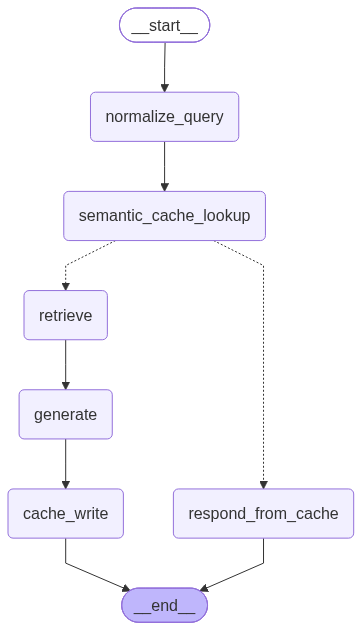

In [8]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

# Initialize graph
graph = StateGraph(RAGState)

# Register nodes
graph.add_node('normalize_query', normalize_query)
graph.add_node('semantic_cache_lookup', semantic_cache_lookup)
graph.add_node('respond_from_cache', respond_from_cache)
graph.add_node('retrieve', retrieve)
graph.add_node('generate', generate)
graph.add_node('cache_write', cache_write)

# Set entry and linear transitions
graph.set_entry_point('normalize_query')
graph.add_edge('normalize_query', 'semantic_cache_lookup')

# Conditional branching based on cache hit
def _branch(state: RAGState) -> str:
    return 'respond_from_cache' if state.get('cache_hit') else 'retrieve'

graph.add_conditional_edges(
    'semantic_cache_lookup',
    _branch,
    {
        'respond_from_cache': 'respond_from_cache',
        'retrieve': 'retrieve',
    },
)

# Branch completions
graph.add_edge('respond_from_cache', END)
graph.add_edge('retrieve', 'generate')
graph.add_edge('generate', 'cache_write')
graph.add_edge('cache_write', END)

# Compile with memory checkpointer
app = graph.compile(checkpointer=MemorySaver())
print('LangGraph CAG workflow compiled successfully!\n')

# Display compiled workflow graph
app


## Step 6: Live Multi-Query Demonstration (Semantic Cache Hits)

We now execute a sequence of queries to demonstrate semantic caching in action:
1. **Query 1**: `"What is LangGraph ?"` $\rightarrow$ **Cache Miss** (initializes cache entry).
2. **Query 2**: `"Explain about LangGraph ?"` $\rightarrow$ **SEMANTIC CACHE HIT!** (Identifies semantic equivalence, zero LLM tokens).
3. **Query 3**: `"Explain about LangGraph agents ?"` $\rightarrow$ **Cache Miss** (Semantically distinct sub-topic, retrieves & memoizes).
4. **Query 4**: `"Explain about agents in Langgraph ?"` $\rightarrow$ **SEMANTIC CACHE HIT!** (Matches Query 3 semantically, zero LLM tokens).


In [9]:
thread_cfg = {'configurable': {'thread_id': 'cag-session-1'}}

# ------------------------------------------------------------------
# Test 1: What is LangGraph ? (Cache Miss expected)
# ------------------------------------------------------------------
print('=' * 75)
print('TEST 1: "What is LangGraph ?"')
print('=' * 75)
start = time.time()
out1 = app.invoke({'question': 'What is LangGraph ?', 'context_docs': [], 'citations': []}, thread_cfg)
elapsed1 = time.time() - start
print(f'Execution Time : {elapsed1:.2f} seconds')
print(f'Cache Hit?     : {out1.get("cache_hit")}')
print(f'Distance       : {out1.get("distance")}')
print(f'Answer         : {out1["answer"]}\n')

# ------------------------------------------------------------------
# Test 2: Explain about LangGraph ? (Semantic Cache Hit expected!)
# ------------------------------------------------------------------
print('=' * 75)
print('TEST 2: "Explain about LangGraph ?"')
print('=' * 75)
start = time.time()
out2 = app.invoke({'question': 'Explain about LangGraph ?', 'context_docs': [], 'citations': []}, thread_cfg)
elapsed2 = time.time() - start
print(f'Execution Time : {elapsed2:.2f} seconds (Near Instantaneous!)')
print(f'Cache Hit?     : {out2.get("cache_hit")}')
print(f'Distance       : {out2.get("distance"):.4f}')
print(f'Answer         : {out2["answer"]}\n')

# ------------------------------------------------------------------
# Test 3: Explain about LangGraph agents ? (Cache Miss expected)
# ------------------------------------------------------------------
print('=' * 75)
print('TEST 3: "Explain about LangGraph agents ?"')
print('=' * 75)
start = time.time()
out3 = app.invoke({'question': 'Explain about LangGraph agents ?', 'context_docs': [], 'citations': []}, thread_cfg)
elapsed3 = time.time() - start
print(f'Execution Time : {elapsed3:.2f} seconds')
print(f'Cache Hit?     : {out3.get("cache_hit")}')
print(f'Distance       : {out3.get("distance"):.4f}')
print(f'Answer         : {out3["answer"]}\n')

# ------------------------------------------------------------------
# Test 4: Explain about agents in Langgraph ? (Semantic Cache Hit expected!)
# ------------------------------------------------------------------
print('=' * 75)
print('TEST 4: "Explain about agents in Langgraph ?"')
print('=' * 75)
start = time.time()
out4 = app.invoke({'question': 'Explain about agents in Langgraph ?', 'context_docs': [], 'citations': []}, thread_cfg)
elapsed4 = time.time() - start
print(f'Execution Time : {elapsed4:.2f} seconds (Near Instantaneous!)')
print(f'Cache Hit?     : {out4.get("cache_hit")}')
print(f'Distance       : {out4.get("distance"):.4f}')
print(f'Answer         : {out4["answer"]}\n')


TEST 1: "What is LangGraph ?"
  >>> [CACHE MISS] Querying RAG knowledge store...
  >>> Generating new answer via Groq LLM (openai/gpt-oss-120b)...
  >>> Memoized new Q&A pair into QA_CACHE (total entries: 1).
Execution Time : 0.88 seconds
Cache Hit?     : False
Distance       : None
Answer         : LangGraph is a framework for building stateful, LLM‑driven workflows as directed computation graphs. It lets you compose agents and other components into cyclic graphs, supports conditional edges for autonomous routing and tool‑use decisions, caches node outputs to memoize results, and provides checkpointers that preserve thread‑scoped state across multi‑turn dialogues【doc-3】【doc-2】【doc-1】【doc-4】.

TEST 2: "Explain about LangGraph ?"
  >>> [CACHE HIT] Match found (distance: 0.1713 <= 0.35)
  >>> Serving response directly from Semantic QA Cache.
Execution Time : 0.02 seconds (Near Instantaneous!)
Cache Hit?     : True
Distance       : 0.1713
Answer         : LangGraph is a framework for buil

## Step 7: Inspect the Populated Semantic QA Cache

We inspect the contents of `QA_CACHE` to observe how question embeddings and answers are memoized.


In [10]:
print(f'Total Q&A pairs stored in QA_CACHE: {QA_CACHE.index.ntotal}\n')

for doc_id, doc in QA_CACHE.docstore._dict.items():
    print(f'Cached Question: "{doc.page_content}"')
    print(f'Cached Answer  : "{doc.metadata.get("answer")[:120]}..."')
    print(f'Timestamp      : {doc.metadata.get("ts")}\n')


Total Q&A pairs stored in QA_CACHE: 2

Cached Question: "what is langgraph ?"
Cached Answer  : "LangGraph is a framework for building stateful, LLM‑driven workflows as directed computation graphs. It lets you compose..."
Timestamp      : 1790354080.2390003

Cached Question: "explain about langgraph agents ?"
Cached Answer  : "LangGraph agents are built as **stateful, cyclic computation graphs** that let a language model decide how to move throu..."
Timestamp      : 1790354081.290943



## Summary

| Component | Technology | Role |
|---|---|---|
| **Embeddings** | HuggingFace `sentence-transformers/all-MiniLM-L6-v2` | Dense 384-dimensional vector space for distance checks |
| **Semantic Cache** | FAISS `IndexFlatL2` + `InMemoryDocstore` | High-speed vector index for question similarity matching |
| **LLM Engine** | Groq `openai/gpt-oss-120b` (`init_chat_model`) | Fast high-throughput reasoning and QA generation |
| **Knowledge Store** | FAISS Vector Store | In-memory RAG corpus queried on cache misses |
| **Orchestration** | LangGraph `StateGraph` | Dynamic branching between cache return and RAG generation |

### Architectural Comparison: Standard RAG vs Exact-Match Caching vs Semantic CAG

| Feature | Standard RAG | Exact-Match Caching | Semantic CAG (LangGraph) |
|---|---|---|---|
| **Latency on Repeated Queries** | ❌ Full LLM delay (2–5s) | ✅ 0.00s | ✅ **0.00s – 0.05s** |
| **Rephrased Query Tolerance** | ❌ Always re-runs | ❌ Cache miss (fails) | ✅ **Cache Hit via Vector Proximity** |
| **Token & API Costs** | ❌ Incurred every time | ⚠️ Only for identical text | ✅ **Zero tokens for semantically similar questions** |
| **Dynamic Self-Populating** | ❌ No caching | ⚠️ Manual key-value | ✅ **Autonomous `cache_write` on misses** |
| **Distance Threshold Tuning** | ❌ Not applicable | ❌ Not applicable | ✅ **Configurable $L_2$ distance gate** |
